### Problem 1

#### (a)

因为要在所有顶点 $y\in\{0,1\}^N$ 上让 $f_x(y)$ 尽量接近 $g(y)$，最自然的最小二乘模型是
$$
\min_{x\in\mathbb{R}^N} \sum_{y\in\{0,1\}^N} \left( \sum_{i=1}^N x_i y_i - \sum_{i=2}^N y_{i-1}y_i \right)^2.
$$

也可以写成矩阵形式：令矩阵 $A\in\mathbb{R}^{2^N\times N}$ 的每一行是一个顶点 $y^T$，向量 $b\in\mathbb{R}^{2^N}$ 的每个分量是对应的 $g(y)$，则问题等价于
$$
\min_{x\in\mathbb{R}^N} \|Ax-b\|_2^2.
$$

#### (b)

##### Case 1: $N=2$

此时
$$
g(y_1,y_2)=y_1y_2,\qquad f_x(y_1,y_2)=x_1y_1+x_2y_2.
$$
在四个顶点 $(0,0),(0,1),(1,0),(1,1)$ 上的误差平方和为
$$
L(x_1,x_2)=x_2^2+x_1^2+(x_1+x_2-1)^2.
$$
对 $x_1,x_2$ 求偏导并令其为零：
$$
\frac{\partial L}{\partial x_1}=2x_1+2(x_1+x_2-1)=0,
$$
$$
\frac{\partial L}{\partial x_2}=2x_2+2(x_1+x_2-1)=0.
$$
即
$$
2x_1+x_2=1,\qquad x_1+2x_2=1.
$$
解得
$$
x^*=\begin{bmatrix}1/3\\[2mm]1/3\end{bmatrix}.
$$

##### Case 2: $N=3$

此时
$$
g(y_1,y_2,y_3)=y_1y_2+y_2y_3,\qquad f_x(y)=x_1y_1+x_2y_2+x_3y_3.
$$
最小二乘的正规方程为
$$
\mathbb{E}[yy^T]x=\mathbb{E}[y\,g(y)],
$$
其中 $y$ 在 $\{0,1\}^3$ 上均匀分布。计算得到
$$
\mathbb{E}[yy^T]=
\begin{bmatrix}
1/2 & 1/4 & 1/4\\
1/4 & 1/2 & 1/4\\
1/4 & 1/4 & 1/2
\end{bmatrix},
\qquad
\mathbb{E}[y\,g(y)]=
\begin{bmatrix}
3/8\\
1/2\\
3/8
\end{bmatrix}.
$$
因此
$$
\begin{bmatrix}
1/2 & 1/4 & 1/4\\
1/4 & 1/2 & 1/4\\
1/4 & 1/4 & 1/2
\end{bmatrix}
\begin{bmatrix}
x_1\\x_2\\x_3
\end{bmatrix}
=
\begin{bmatrix}
3/8\\1/2\\3/8
\end{bmatrix}.
$$
由对称性可设 $x_1=x_3=a$，$x_2=b$。则有
$$
3a+b=\frac{3}{2},\qquad a+b=1.
$$
解得
$$
a=\frac{1}{4},\qquad b=\frac{3}{4}.
$$
所以
$$
x^*=\begin{bmatrix}1/4\\[2mm]3/4\\[2mm]1/4\end{bmatrix}.
$$


In [ ]:
"""Problem 1(c) (Optional)"""
import numpy as np

def solve_problem1_fast(N: int) -> np.ndarray:

    # Normal equations are E[yy^T] x = E[y g(y)].
    # For y_i ~ Bernoulli(1/2), E[yy^T] has diagonal 1/2 and off-diagonal 1/4,
    # so it can be written as (I + 11^T) / 4.
    # The right-hand side has endpoint entries N/8 and interior entries (N+1)/8.
    rhs = np.full(N, (N + 1) / 8.0)
    rhs[0] = rhs[-1] = N / 8.0

    # Let s = sum_i x_i. From (I + 11^T)x = 4 rhs, we get x_i + s = 4 rhs_i.
    s = 4.0 * rhs.sum() / (N + 1)
    x = 4.0 * rhs - s
    return x

N = 100
x_star = solve_problem1_fast(N)

print(f"N = {N}")
print(f"x_1 = x_{N} = {x_star[0]:.10f}")
print(f"x_2 = ... = x_{N-1} = {x_star[1]:.10f}")
print()
print("Full solution vector x*:")
print(np.array2string(x_star, precision=10, separator=", "))

# Closed-form pattern:
# x_1 = x_N = 1 / (N + 1)
# x_i = (N + 3) / (2 * (N + 1)),  i = 2, ..., N-1


N = 100
x_1 = x_100 = 0.0099009901
x_2 = ... = x_99 = 0.5099009901

Full solution vector x*:
[0.0099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901,
 0.5099009901, 0.5099009901, 0.5099009901, 0.5099009901

### Problem 2

#### (a)

题目给定状态向量
$$
x_t=
\begin{bmatrix}
x_t\\ y_t\\ z_t\\ v_{x,t}\\ v_{y,t}\\ v_{z,t}
\end{bmatrix}.
$$

在 constant velocity model 且 $\Delta t=1$ 的条件下，有
$$
\begin{aligned}
x_{t+1} &= x_t + v_{x,t},\\
y_{t+1} &= y_t + v_{y,t},\\
z_{t+1} &= z_t + v_{z,t},\\
v_{x,t+1} &= v_{x,t},\\
v_{y,t+1} &= v_{y,t},\\
v_{z,t+1} &= v_{z,t}.
\end{aligned}
$$
因此
$$
A=
\begin{bmatrix}
1&0&0&1&0&0\\
0&1&0&0&1&0\\
0&0&1&0&0&1\\
0&0&0&1&0&0\\
0&0&0&0&1&0\\
0&0&0&0&0&1
\end{bmatrix},
\qquad
H=
\begin{bmatrix}
1&0&0&0&0&0\\
0&1&0&0&0&0\\
0&0&1&0&0&0
\end{bmatrix}.
$$

其中观测矩阵 $H$ 只保留位置分量，因为数据里只有位置观测，没有速度观测。题目还给定
$$
Q=10^{-5}I_6,
\qquad
R=\mathrm{diag}(0.01^2,0.015^2,0.02^2),
\qquad
\hat{x}_0=0,
\qquad
P_0=0.01I_6.
$$


Data file: spaceship_trajectory3D.csv
RMSE in x: 0.008331
RMSE in y: 0.012090
RMSE in z: 0.012956
Overall position RMSE: 0.019581


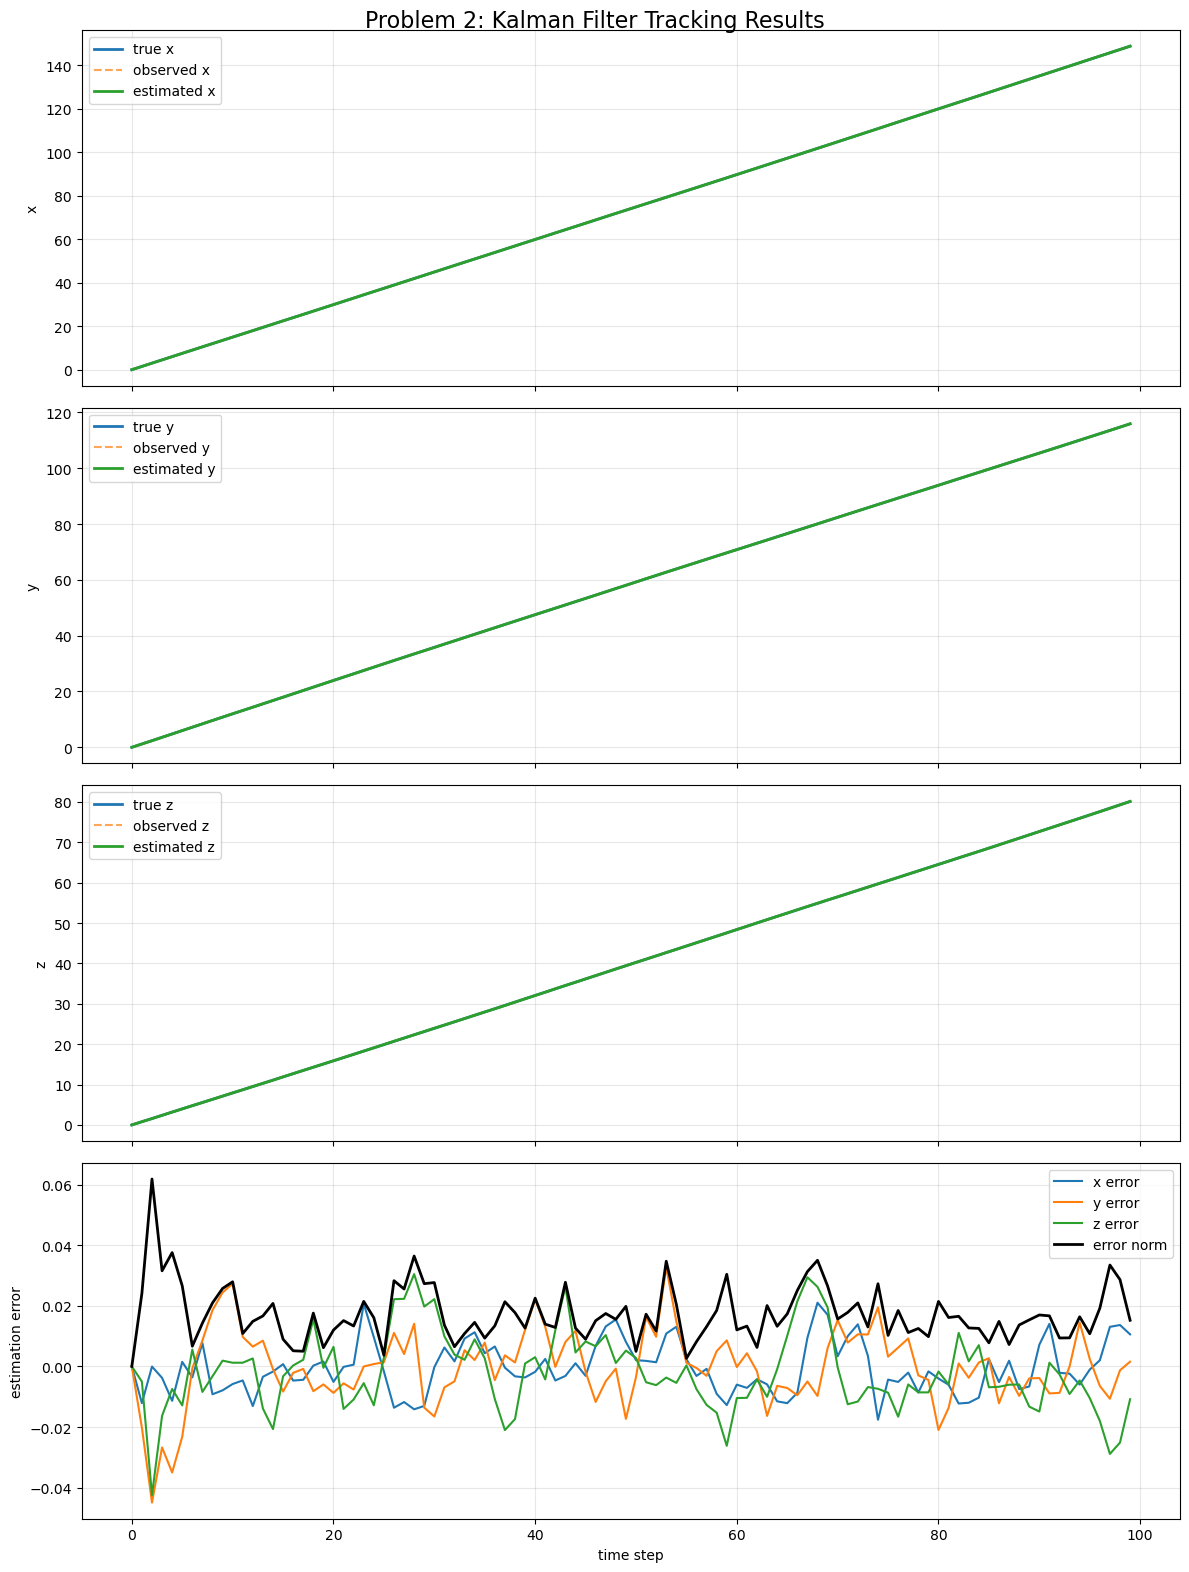

In [ ]:
"""Problem 2"""
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_data_file() -> Path:
    candidates = [
        Path("spaceship_trajectory3D.csv"),
        Path("Lecture4/spaceship_trajectory3D.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Could not find spaceship_trajectory3D.csv")


def run_kalman_filter(csv_path: Path):
    data = np.genfromtxt(csv_path, delimiter=",", names=True)

    t = data["t"]
    true_pos = np.column_stack([data["x_true"], data["y_true"], data["z_true"]])
    obs_pos = np.column_stack([data["x_obs"], data["y_obs"], data["z_obs"]])

    dt = 1.0
    A = np.array([
        [1, 0, 0, dt, 0, 0],
        [0, 1, 0, 0, dt, 0],
        [0, 0, 1, 0, 0, dt],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1],
    ], dtype=float)
    H = np.array([
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
    ], dtype=float)

    Q = 1e-5 * np.eye(6)
    R = np.diag([0.01**2, 0.015**2, 0.02**2])

    x_hat = np.zeros(6)
    P = 0.01 * np.eye(6)
    estimates = np.zeros((len(t), 6))
    estimates[0] = x_hat

    for k in range(1, len(t)):
        z_k = obs_pos[k]

        x_pred = A @ x_hat
        P_pred = A @ P @ A.T + Q

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        innovation = z_k - H @ x_pred
        x_hat = x_pred + K @ innovation
        P = (np.eye(6) - K @ H) @ P_pred

        estimates[k] = x_hat

    return t, true_pos, obs_pos, estimates


csv_path = find_data_file()
t, true_pos, obs_pos, estimates = run_kalman_filter(csv_path)
est_pos = estimates[:, :3]
errors = est_pos - true_pos
rmse = np.sqrt(np.mean(errors**2, axis=0))

print(f"Data file: {csv_path}")
print(f"RMSE in x: {rmse[0]:.6f}")
print(f"RMSE in y: {rmse[1]:.6f}")
print(f"RMSE in z: {rmse[2]:.6f}")
print(f"Overall position RMSE: {np.sqrt(np.mean(np.sum(errors**2, axis=1))):.6f}")

labels = ["x", "y", "z"]
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for i, label in enumerate(labels):
    axes[i].plot(t, true_pos[:, i], label=f"true {label}", linewidth=2)
    axes[i].plot(t, obs_pos[:, i], label=f"observed {label}", linestyle="--", alpha=0.7)
    axes[i].plot(t, est_pos[:, i], label=f"estimated {label}", linewidth=2)
    axes[i].set_ylabel(label)
    axes[i].grid(alpha=0.3)
    axes[i].legend(loc="best")

axes[3].plot(t, errors[:, 0], label="x error")
axes[3].plot(t, errors[:, 1], label="y error")
axes[3].plot(t, errors[:, 2], label="z error")
axes[3].plot(t, np.linalg.norm(errors, axis=1), label="error norm", color="black", linewidth=2)
axes[3].set_xlabel("time step")
axes[3].set_ylabel("estimation error")
axes[3].grid(alpha=0.3)
axes[3].legend(loc="best")

fig.suptitle("Problem 2: Kalman Filter Tracking Results", fontsize=16)
plt.tight_layout()
plt.show()


#### (c) Show equivalence with weighted least squares

记
$$
x_{pred}=A\hat{x}_{t-1}.
$$
考虑下面的目标函数：
$$
J(x)=(z_t-Hx)^TR^{-1}(z_t-Hx)+(x-x_{pred})^TP_{pred}^{-1}(x-x_{pred}).
$$
第一项衡量当前状态 $x$ 对观测的拟合误差，第二项衡量当前状态 $x$ 偏离先验预测 $x_{pred}$ 的程度。

对 $x$ 求梯度并令其为零：
$$
-2H^TR^{-1}(z_t-Hx)+2P_{pred}^{-1}(x-x_{pred})=0.
$$
整理得到正规方程
$$
(H^TR^{-1}H+P_{pred}^{-1})x=H^TR^{-1}z_t+P_{pred}^{-1}x_{pred}.
$$
因此最优解为
$$
\hat{x}_t=(H^TR^{-1}H+P_{pred}^{-1})^{-1}(H^TR^{-1}z_t+P_{pred}^{-1}x_{pred}).
$$

现在使用 Matrix Inversion Lemma（Woodbury 公式），取
$$
X=P_{pred}^{-1},
\qquad U=H^T,
\qquad W=R,
\qquad V=H.
$$
则有
$$
(P_{pred}^{-1}+H^TR^{-1}H)^{-1}
=P_{pred}-P_{pred}H^T(HP_{pred}H^T+R)^{-1}HP_{pred}.
$$
记
$$
K_t=P_{pred}H^T(HP_{pred}H^T+R)^{-1},
$$
就得到
$$
(P_{pred}^{-1}+H^TR^{-1}H)^{-1}=(I-K_tH)P_{pred}.
$$
代回上式后可化简为
$$
\hat{x}_t=x_{pred}+K_t(z_t-Hx_{pred}),
$$
这正是 Kalman filter 的更新公式。所以 Kalman 更新本质上就是一个加权最小二乘问题：一边拟合当前观测，一边保持与上一时刻预测的一致性。
